In [1]:
from rocketpy import Environment
from rocketpy import PointMassMotor
from rocketpy import PointMassRocket
from rocketpy.simulation import FlightDataExporter


In [2]:
env = Environment(
    latitude=32.990254,
    longitude=-106.974998,
    elevation=10
)
env.set_atmospheric_model(type="standard_atmosphere")


In [3]:
# Using a thrust curve file
motor = PointMassMotor(
    thrust_source=800,
    dry_mass= 3.6599000000000004,
    propellant_initial_mass = 3.095,
    burn_time = 6
)

In [4]:
rocket = PointMassRocket(
    radius=0.057,  # meters
    mass=10.385,  # kg (dry mass without motor)
    center_of_mass_without_motor=0.0,
    power_off_drag=0.75,  # Constant drag coefficient
    power_on_drag=0.75,
)

rocket.add_motor(motor, position = 0)



In [5]:
from rocketpy import Flight

flight = Flight(
    rocket=rocket,
    environment=env,
    rail_length=5,
    inclination=85,  
    heading= -15,  
    simulation_mode="3 DOF",
    terminate_on_apogee=False,
)


In [6]:
# print results
flight.prints.apogee_conditions()
flight.prints.impact_conditions()




Apogee State

Apogee Time: 22.197 s
Apogee Altitude: 2178.258 m (ASL) | 2168.258 m (AGL)
Apogee Freestream Speed: 18.571 m/s
Apogee X position: -101.202 m
Apogee Y position: 377.692 m
Apogee latitude: 32.9936502°
Apogee longitude: -106.9760830°

Impact Conditions

Time of impact: 41.026 s
X impact: -181.897 m
Y impact: 678.849 m
Altitude impact: 10.000 m (ASL) | -0.000 m (AGL) 
Latitude: 32.9963582°
Longitude: -106.9769482°
Vertical velocity at impact: -299.616 m/s
Number of parachutes triggered until impact: 0


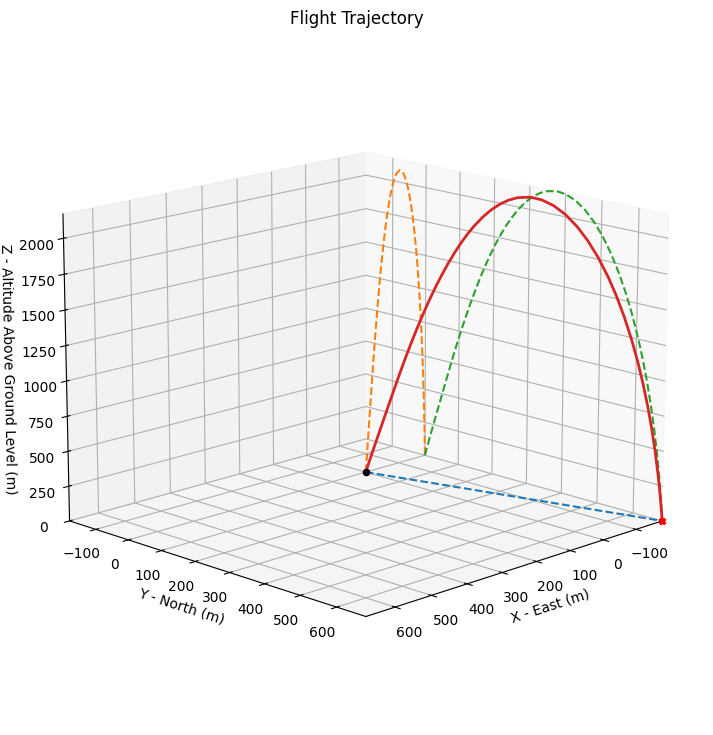

In [7]:
# plot results
flight.plots.trajectory_3d()

In [8]:
# export data
exporter = FlightDataExporter(flight)
exporter.export_data(
    "rocketpy_trajectory_3dof.csv",
    "x",
    "y",
    "z",
    "vx",
    "vy",
    "vz",
)